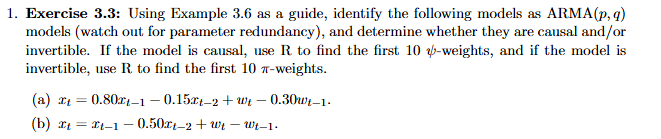

#### (A)

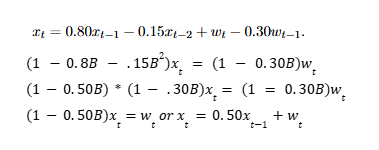
True model is ARMA(1,0)

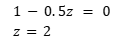

2 > |1|, thus model is causal. Model is default invertible since MA(0)

The first 10 weights are:

In [1]:
weights = []
i = 1
while i <= 10:
    weight = 0.5**i
    weights.append(weight)
    i += 1
print(weights)

[0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125, 0.0009765625]


#### (B)

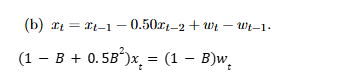

Plugging in B = 1 into left side of equation shows
that there is no parameter redundancy as no
terms cancel out


The model is thus an ARMA(2,1)

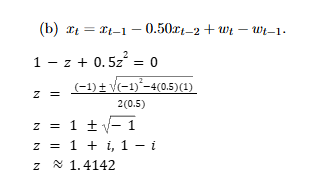

1.4142 > 1, thus model is causal. The first 10 weights are:

In [2]:
psi = [1, 0]
i = 2
while i <= 10:
    weight = psi[i-1] - 0.5 * psi[i-2]
    psi.append(weight)
    i += 1
psi = psi[1:]
print(psi)

[0, -0.5, -0.5, -0.25, 0.0, 0.125, 0.125, 0.0625, 0.0, -0.03125]


z = 1, z !> |1|, thus model is not invertible

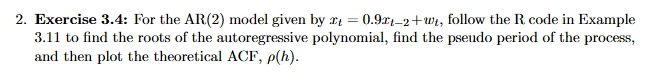

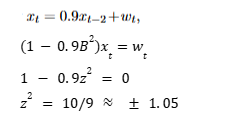

The roots are thus 1.05, -1.05 (causal)

Since the roots are real numbers > 1, there is no pesudo process

Note from textbook:
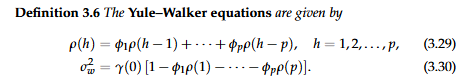
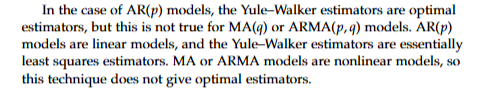

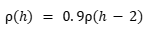

Finding and plotting theoretical ACF

In [3]:
acfs = []
lag0 = 1
lag1 = 0
acfs.append(lag0)
acfs.append(lag1)
lag = 2
while lag <= 50:
    lagh = 0.9 * acfs[lag-2]
    acfs.append(lagh)
    lag += 1

([<matplotlib.axis.XTick at 0x16281a30590>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50')])

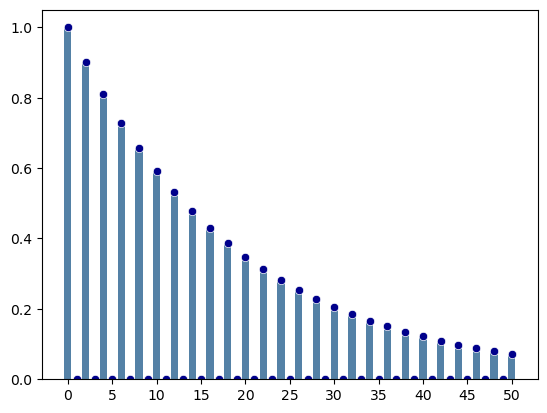

In [4]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
lagIndex = np.arange(0, 51, 1)
sns.barplot(x=lagIndex, y=acfs, color="steelblue")
sns.scatterplot(x=lagIndex, y=acfs, color ="darkblue")
plt.xticks(np.arange(0,51,5))

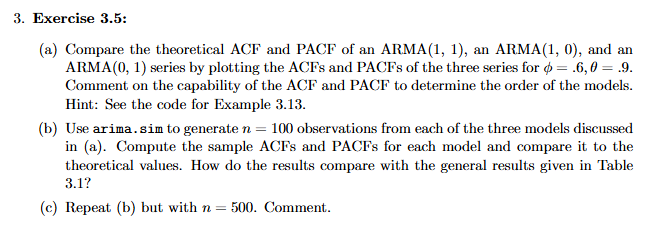

(A)

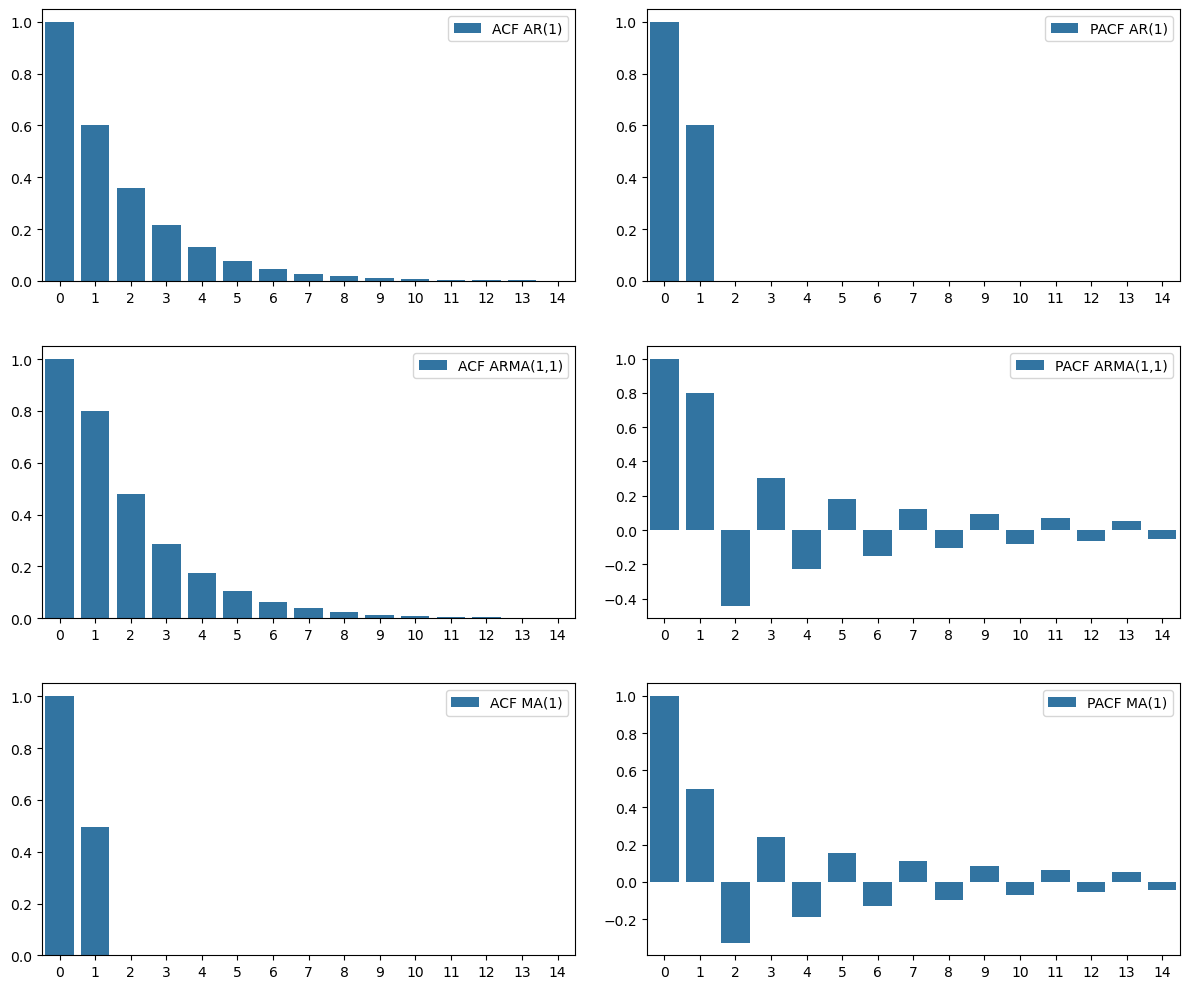

In [5]:
import statsmodels.tsa.arima_process as arimap
phi = np.array([1, -0.6])
theta = np.array([1, 0.9])
lags = 15
acfAR1 = arimap.arma_acf(phi, [1], lags=lags)
pacfAR1 = arimap.arma_pacf(phi, [1], lags=lags)
acfARMA11 = arimap.arma_acf(phi, theta, lags=lags)
pacfARMA11 = arimap.arma_pacf(phi, theta, lags=lags)
acfMA1 = arimap.arma_acf([1], theta, lags=lags)
pacfMA1 = arimap.arma_pacf([1], theta, lags=lags)
lagsIndex = np.arange(lags)
fig, axes = plt.subplots(3,2, figsize=(12,10))
sns.barplot(x=lagsIndex, y=acfAR1, ax=axes[0,0], label="ACF AR(1)")
sns.barplot(x=lagsIndex, y=pacfAR1, ax=axes[0,1], label="PACF AR(1)")
sns.barplot(x=lagsIndex, y=acfARMA11, ax=axes[1,0], label="ACF ARMA(1,1)")
sns.barplot(x=lagsIndex, y=pacfARMA11, ax=axes[1,1], label="PACF ARMA(1,1)")
sns.barplot(x=lagsIndex, y=acfMA1, ax=axes[2,0], label="ACF MA(1)")
sns.barplot(x=lagsIndex, y=pacfMA1, ax=axes[2,1], label="PACF MA(1)")

for ax in axes.flat:
    ax.set_xticks(np.arange(0, lags, 1))
plt.tight_layout(h_pad=3.0, w_pad=2.0)

(B)

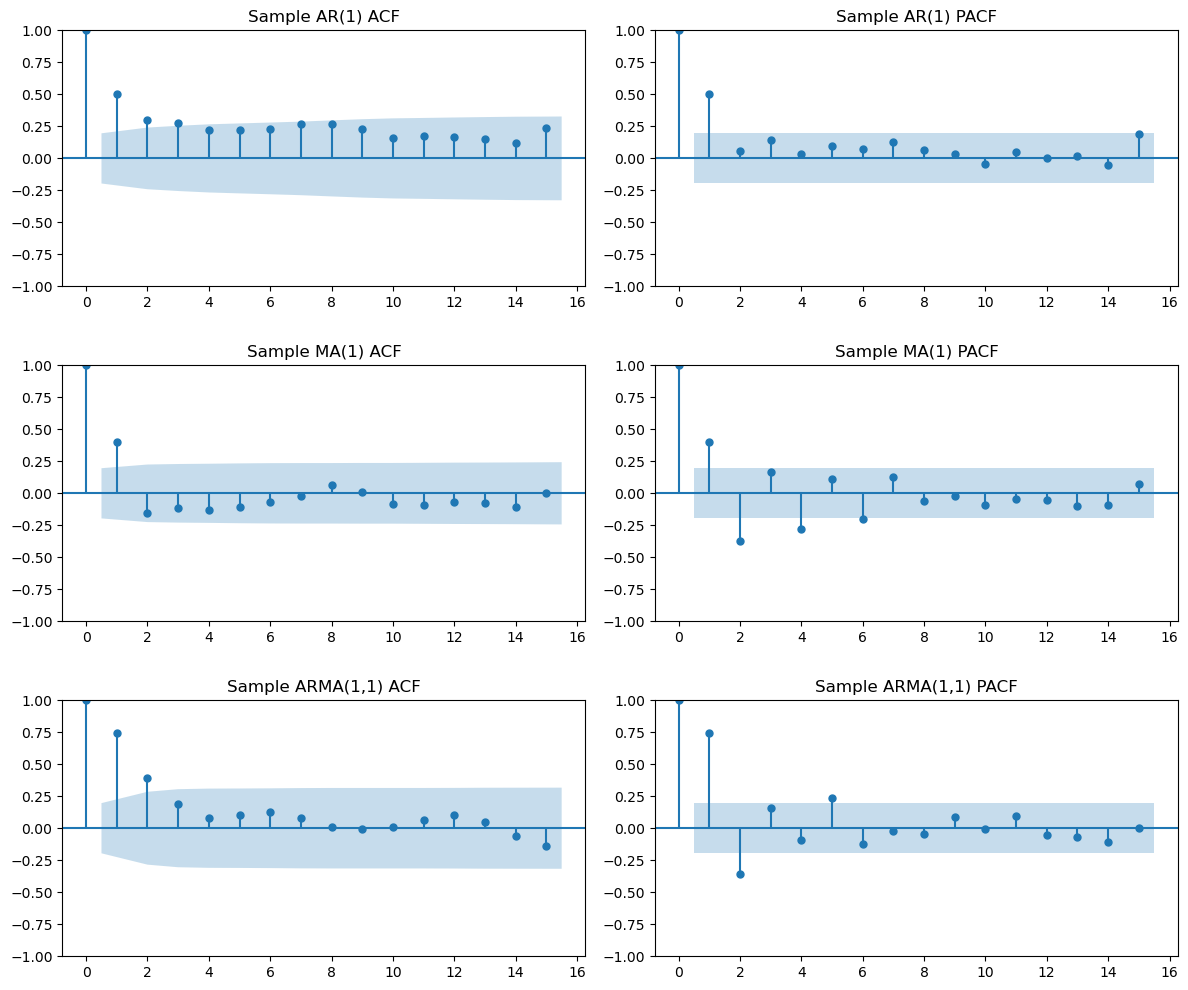

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
phi = np.array([1, -0.6])
theta = np.array([1, 0.9])
lags = 15
n = 100

ar1sample = arimap.arma_generate_sample(phi, [1], nsample=n)
ma1sample = arimap.arma_generate_sample([1], theta, nsample=n)
arma11sample = arimap.arma_generate_sample(phi, theta, nsample=n)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
plot_acf(ar1sample, ax=axes[0, 0], lags=lags, title="Sample AR(1) ACF")
plot_pacf(ar1sample, ax=axes[0, 1], lags=lags, title="Sample AR(1) PACF")
plot_acf(ma1sample, ax=axes[1, 0], lags=lags, title="Sample MA(1) ACF")
plot_pacf(ma1sample, ax=axes[1, 1], lags=lags, title="Sample MA(1) PACF")
plot_acf(arma11sample, ax=axes[2, 0], lags=lags, title="Sample ARMA(1,1) ACF")
plot_pacf(arma11sample, ax=axes[2, 1], lags=lags, title="Sample ARMA(1,1) PACF")
plt.tight_layout(h_pad=2.5)

At n=100, the results of the sample plots generally follow their theoretical counterparts, but of course random noise causes some major deviations.

(C)

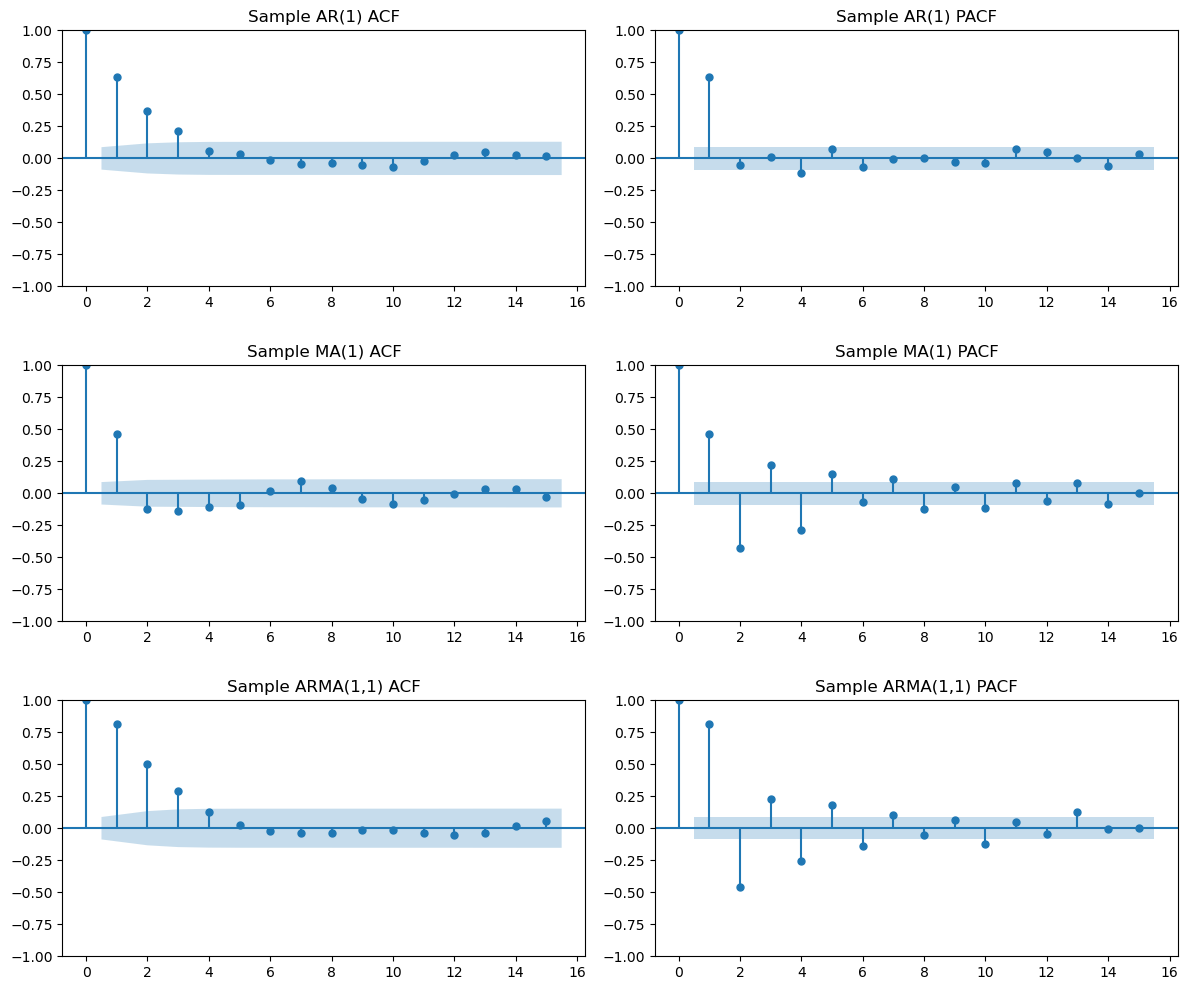

In [7]:
phi = np.array([1, -0.6])
theta = np.array([1, 0.9])
lags = 15
n = 500

ar1sample = arimap.arma_generate_sample(phi, [1], nsample=n)
ma1sample = arimap.arma_generate_sample([1], theta, nsample=n)
arma11sample = arimap.arma_generate_sample(phi, theta, nsample=n)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
plot_acf(ar1sample, ax=axes[0, 0], lags=lags, title="Sample AR(1) ACF")
plot_pacf(ar1sample, ax=axes[0, 1], lags=lags, title="Sample AR(1) PACF")
plot_acf(ma1sample, ax=axes[1, 0], lags=lags, title="Sample MA(1) ACF")
plot_pacf(ma1sample, ax=axes[1, 1], lags=lags, title="Sample MA(1) PACF")
plot_acf(arma11sample, ax=axes[2, 0], lags=lags, title="Sample ARMA(1,1) ACF")
plot_pacf(arma11sample, ax=axes[2, 1], lags=lags, title="Sample ARMA(1,1) PACF")
plt.tight_layout(h_pad=2.5)

At n=500, the sample plots align much more closely with their theoretical counterparts, but some sampling variance is still observable.

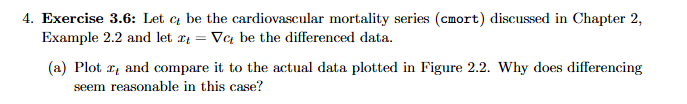
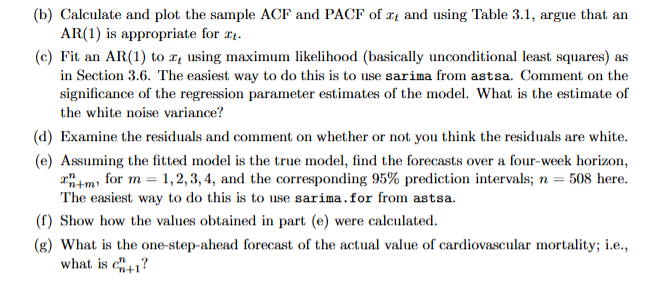

<Axes: xlabel='Time'>

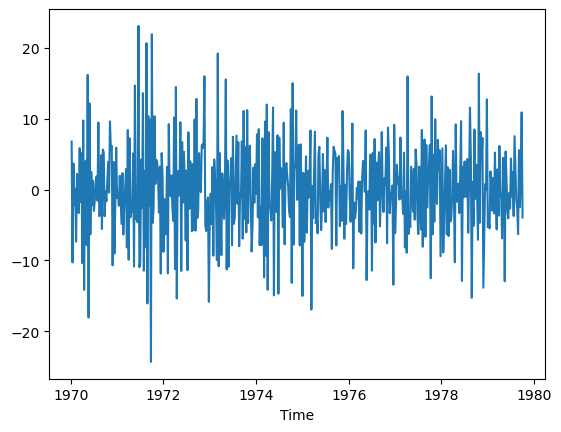

In [8]:
import pandas as pd
df = pd.read_csv("cmort.csv")
#I think ASTSA github cmort data is slightly different than that in R library since git data only has index + mortality but R package has temp/pollution/etc.
xT = df['Value']
xT = np.diff(xT)
xIndex=df['Time'][1:]
sns.lineplot(x=xIndex, y=xT)

Figure 2.2:

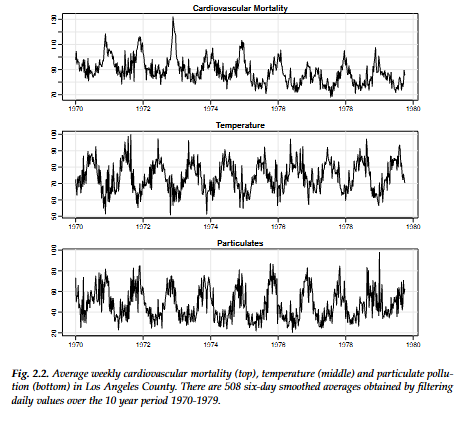

Differencing in this case seems reasonable as the original series has a clean downward drift / non-constant mean. By differencing we are able to use an ARMA model.

(B)

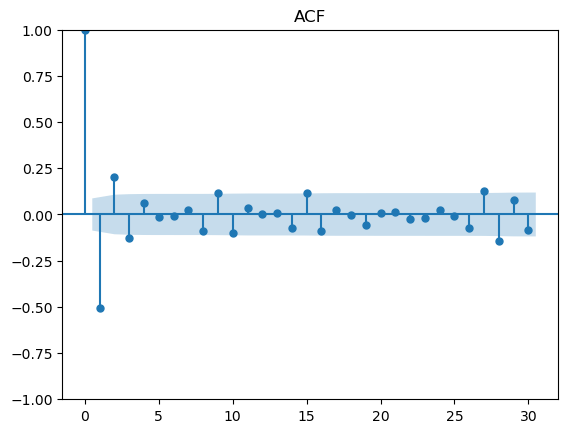

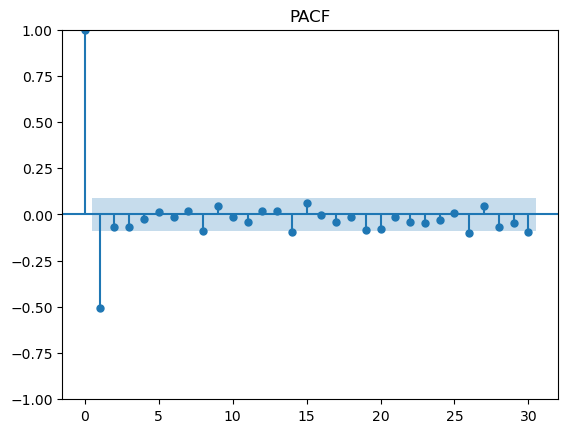

In [9]:
plot_acf(xT, lags = 30, title = "ACF");
plot_pacf(xT, lags = 30, title = "PACF");

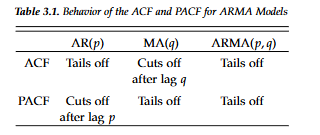

ACF: Gradually Decays
PACF: Cuts off after lag(1)
Thus, AR(1) is best


(C)

In [10]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(xT, order=(1,0,0))
fit = model.fit()
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  507
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1612.054
Date:                Thu, 09 Jul 2026   AIC                           3230.109
Time:                        20:00:54   BIC                           3242.794
Sample:                             0   HQIC                          3235.083
                                - 507                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0263      0.172     -0.153      0.879      -0.363       0.311
ar.L1         -0.5064      0.037    -13.538      0.000      -0.580      -0.433
sigma2        33.8088      2.008     16.834      0.0

All terms except for the constant are statistically significant. This is expected since we differenced the data and expect a mean of zero. The estimate of the white noise variance (sigma2) is 33.8088. The estimate of ar. L1 is -0.5064.

(D)

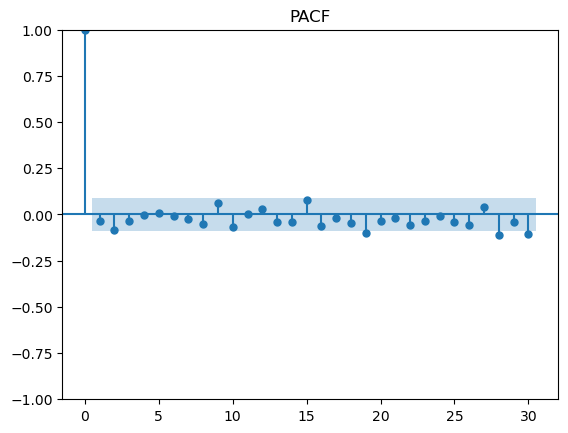

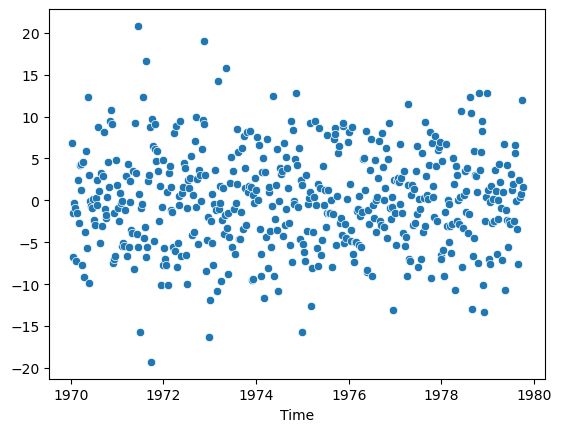

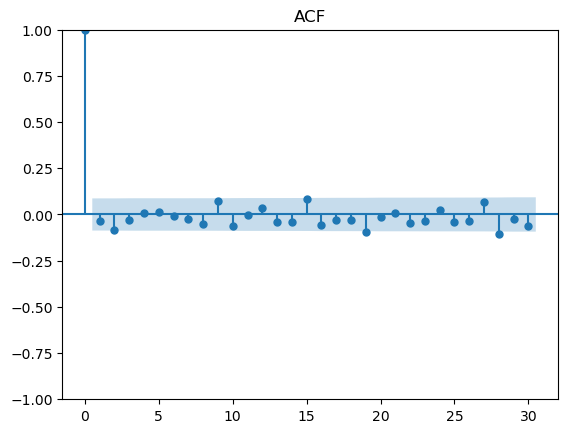

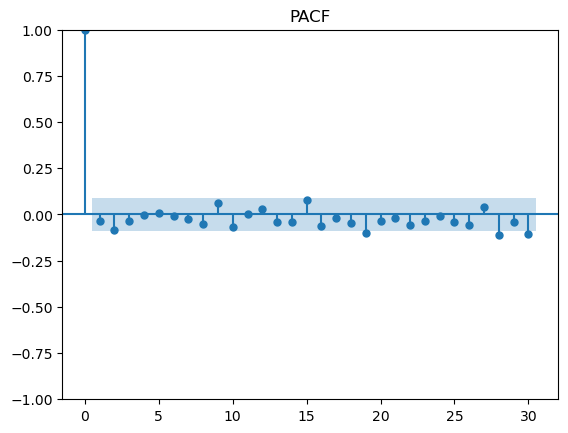

In [11]:
residuals = fit.resid
sns.scatterplot(x=xIndex, y=residuals)
plot_acf(residuals, lags = 30, title ="ACF")
plot_pacf(residuals, lags = 30, title ="PACF")

Looking at the raw residuals over time, they appear random over time. ACF and PACF of the residuals confirm that the residuals do not have any sort of autocorrelation. 

(E)

In [12]:
xTforecast = fit.get_forecast(steps=4)
xTforecastMean = xTforecast.predicted_mean
xTforecastCI = xTforecast.conf_int(alpha=.05)
for i, pred in enumerate(xTforecastMean):
    print(f"Predicted value for week {i+1} is {pred:.3f}, PI is {xTforecastCI[i]}")

Predicted value for week 1 is 1.956, PI is [-9.44068682 13.35185919]
Predicted value for week 2 is -1.030, PI is [-13.80397547  11.74427791]
Predicted value for week 3 is 0.482, PI is [-12.62219618  13.58605612]
Predicted value for week 4 is -0.284, PI is [-13.47102799  12.9038045 ]


(F)

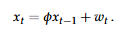

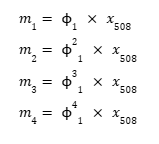

(G)

In [13]:
oneStepForecast = xTforecastMean[0]
lastObservation = df['Value'].iloc[-1]
xT509 = lastObservation + oneStepForecast
print(f"The one-step-ahead forcast of the actual value of cardiovascular mortality is {xT509:3f}")

The one-step-ahead forcast of the actual value of cardiovascular mortality is 87.445586
